# 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

**Domain:** E-Commerce and Retail Analytics  
**Problem Type:** Unsupervised ML (Clustering) + Collaborative Filtering (Recommendation System)

---

## 📣 Problem Statement

The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. This project examines transaction data from an online retail business to:

1. **Segment customers** based on **Recency, Frequency, and Monetary (RFM) analysis** using KMeans clustering
2. **Recommend products** using **Item-based Collaborative Filtering** with cosine similarity
3. **Build a Streamlit app** for real-time predictions and recommendations

## 📌 Real-time Business Use Cases
- Customer Segmentation for Targeted Marketing Campaigns
- Personalized Product Recommendations on E-Commerce Platforms
- Identifying At-Risk Customers for Retention Programs
- Dynamic Pricing Strategies Based on Purchase Behavior
- Inventory Management and Stock Optimization

---

## 📦 Step 0: Import Libraries

In [1]:
# ── Core Data Libraries ──
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Machine Learning ──
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

# ── Similarity / Recommendation ──
from sklearn.metrics.pairwise import cosine_similarity

# ── Model Persistence ──
import pickle
import joblib
import os
import re
from datetime import datetime

print("✅ All libraries imported successfully!")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")

✅ All libraries imported successfully!
Pandas: 2.3.3 | NumPy: 2.4.6


---
## 📂 Step 1: Dataset Collection & Understanding

In [2]:
# ── Load Dataset ──
# Dataset path for Kaggle environment
df = pd.read_csv('/kaggle/input/datasets/deepakyadav027/online-retail/online_retail.csv', encoding='latin1')

print(f"📊 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
df.head(10)

📊 Dataset Shape: 541,909 rows × 8 columns



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2022-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2022-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2022-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2022-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2022-12-01 08:34:00,1.69,13047.0,United Kingdom


In [3]:
# ── Dataset Structure ──
print("📋 Column Data Types:")
print(df.dtypes)
print()
print("📐 Dataset Info:")
df.info()

📋 Column Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

📐 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


### 📌 Dataset Description

| Column | Description |
|--------|-------------|
| **InvoiceNo** | Transaction number |
| **StockCode** | Unique product/item code |
| **Description** | Name of the product |
| **Quantity** | Number of products purchased |
| **InvoiceDate** | Date and time of transaction |
| **UnitPrice** | Price per product |
| **CustomerID** | Unique identifier for each customer |
| **Country** | Country where the customer is based |

In [4]:
# ── Missing Values Analysis ──
print("🔍 Missing Values:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
print(missing_df[missing_df['Missing Count'] > 0])
print()

# ── Duplicate Check ──
print(f"🔁 Duplicate Rows: {df.duplicated().sum():,}")
print()

# ── Cancelled Invoices ──
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"❌ Cancelled Invoices: {len(cancelled):,} rows")
print()

# ── Negative / Zero Quantity & Price ──
print(f"📉 Negative/Zero Quantity rows: {(df['Quantity'] <= 0).sum():,}")
print(f"📉 Negative/Zero UnitPrice rows: {(df['UnitPrice'] <= 0).sum():,}")

🔍 Missing Values:
             Missing Count  Missing %
Description           1454       0.27
CustomerID          135080      24.93

🔁 Duplicate Rows: 5,268

❌ Cancelled Invoices: 9,288 rows

📉 Negative/Zero Quantity rows: 10,624
📉 Negative/Zero UnitPrice rows: 2,517


In [5]:
# ── Statistical Summary ──
print("📊 Statistical Summary:")
df.describe()

📊 Statistical Summary:


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


---
## 🧹 Step 2: Data Preprocessing

In [6]:
raw_count = len(df)
print(f"📌 Raw dataset size: {raw_count:,} rows")

# ── 1. Remove rows with missing CustomerID ──
df_clean = df.dropna(subset=['CustomerID'])
print(f"✅ After removing missing CustomerID: {len(df_clean):,} rows (removed {raw_count - len(df_clean):,})")

# ── 2. Exclude cancelled invoices (InvoiceNo starting with 'C') ──
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f"✅ After removing cancelled invoices: {len(df_clean):,} rows")

# ── 3. Remove negative or zero quantities ──
df_clean = df_clean[df_clean['Quantity'] > 0]
print(f"✅ After removing zero/negative Quantity: {len(df_clean):,} rows")

# ── 4. Remove negative or zero unit prices ──
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print(f"✅ After removing zero/negative UnitPrice: {len(df_clean):,} rows")

# ── 5. Drop duplicates ──
df_clean = df_clean.drop_duplicates()
print(f"✅ After removing duplicates: {len(df_clean):,} rows")

# ── 6. Convert InvoiceDate to datetime ──
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# ── 7. Convert CustomerID to integer ──
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# ── 8. Create TotalAmount feature ──
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"\n🎯 Final clean dataset: {len(df_clean):,} rows × {df_clean.shape[1]} columns")
print(f"📅 Date range: {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")
df_clean.head()

📌 Raw dataset size: 541,909 rows
✅ After removing missing CustomerID: 406,829 rows (removed 135,080)
✅ After removing cancelled invoices: 397,924 rows
✅ After removing zero/negative Quantity: 397,924 rows
✅ After removing zero/negative UnitPrice: 397,884 rows
✅ After removing duplicates: 392,692 rows

🎯 Final clean dataset: 392,692 rows × 9 columns
📅 Date range: 2022-12-01 → 2023-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [7]:
# ── Verify no nulls remain ──
print("🔍 Null values after cleaning:")
print(df_clean.isnull().sum())

🔍 Null values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
TotalAmount    0
dtype: int64


---
## 📊 Step 3: Exploratory Data Analysis (EDA)

### 3.1 Transaction Volume by Country

In [10]:
# ── Top 15 Countries by Transaction Volume ──
country_sales = (df_clean.groupby('Country')
                 .agg(Transactions=('InvoiceNo', 'nunique'),
                      Revenue=('TotalAmount', 'sum'),
                      Customers=('CustomerID', 'nunique'))
                 .sort_values('Revenue', ascending=False)
                 .reset_index())

top15 = country_sales.head(15)

# Print table FIRST so it appears above the chart
print("\n📊 Top 10 Countries Summary:")
print(country_sales.head(10).to_string(index=False))

# Chart below
fig = make_subplots(rows=1, cols=2,
                    subplot_titles=['Top 15 Countries by Revenue', 'Top 15 Countries by Transactions'])

fig.add_trace(
    go.Bar(x=top15['Revenue'], y=top15['Country'], orientation='h',
           marker_color='steelblue', name='Revenue'),
    row=1, col=1)

fig.add_trace(
    go.Bar(x=top15['Transactions'], y=top15['Country'], orientation='h',
           marker_color='coral', name='Transactions'),
    row=1, col=2)

fig.update_layout(height=500, title_text='🌍 Transaction Volume by Country',
                  showlegend=False)
fig.show()


📊 Top 10 Countries Summary:
       Country  Transactions     Revenue  Customers
United Kingdom         16646 7285024.644       3920
   Netherlands            94  285446.340          9
          EIRE           260  265262.460          3
       Germany           457  228678.400         94
        France           389  208934.310         87
     Australia            57  138453.810          9
         Spain            90   61558.560         30
   Switzerland            51   56443.950         21
       Belgium            98   41196.340         25
        Sweden            36   38367.830          8


### 3.2 Top-Selling Products

In [11]:
# ── Top 20 Products by Quantity Sold ──
top_products = (df_clean.groupby('Description')
                .agg(Total_Qty=('Quantity', 'sum'),
                     Total_Revenue=('TotalAmount', 'sum'),
                     Order_Count=('InvoiceNo', 'nunique'))
                .sort_values('Total_Qty', ascending=False)
                .reset_index()
                .head(20))

fig = px.bar(top_products, x='Total_Qty', y='Description',
             orientation='h', color='Total_Revenue',
             color_continuous_scale='Viridis',
             title='🏆 Top 20 Best-Selling Products (by Quantity)',
             labels={'Total_Qty': 'Total Quantity Sold', 'Description': 'Product'},
             height=600)
fig.update_layout(yaxis={'categoryorder': 'total ascending'})
fig.show()

In [12]:
# ── Top 20 Products by Revenue ──
top_by_revenue = (df_clean.groupby('Description')
                  .agg(Total_Revenue=('TotalAmount', 'sum'))
                  .sort_values('Total_Revenue', ascending=False)
                  .reset_index()
                  .head(20))

fig = px.treemap(top_by_revenue, path=['Description'], values='Total_Revenue',
                 title='💰 Top 20 Products by Revenue (Treemap)',
                 color='Total_Revenue', color_continuous_scale='RdYlGn')
fig.show()

### 3.3 Purchase Trends Over Time

In [13]:
# ── Monthly Revenue Trend ──
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly = (df_clean.groupby('YearMonth')
           .agg(Revenue=('TotalAmount', 'sum'),
                Orders=('InvoiceNo', 'nunique'),
                Customers=('CustomerID', 'nunique'))
           .reset_index())
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig = make_subplots(rows=3, cols=1,
                    subplot_titles=['Monthly Revenue', 'Monthly Orders', 'Monthly Unique Customers'],
                    shared_xaxes=True)

fig.add_trace(go.Scatter(x=monthly['YearMonth'], y=monthly['Revenue'],
                          mode='lines+markers', fill='tozeroy',
                          line=dict(color='steelblue'), name='Revenue'),
              row=1, col=1)
fig.add_trace(go.Bar(x=monthly['YearMonth'], y=monthly['Orders'],
                      marker_color='coral', name='Orders'),
              row=2, col=1)
fig.add_trace(go.Scatter(x=monthly['YearMonth'], y=monthly['Customers'],
                          mode='lines+markers', line=dict(color='green'), name='Customers'),
              row=3, col=1)

fig.update_layout(height=700, title_text='📈 Purchase Trends Over Time', showlegend=False)
fig.show()

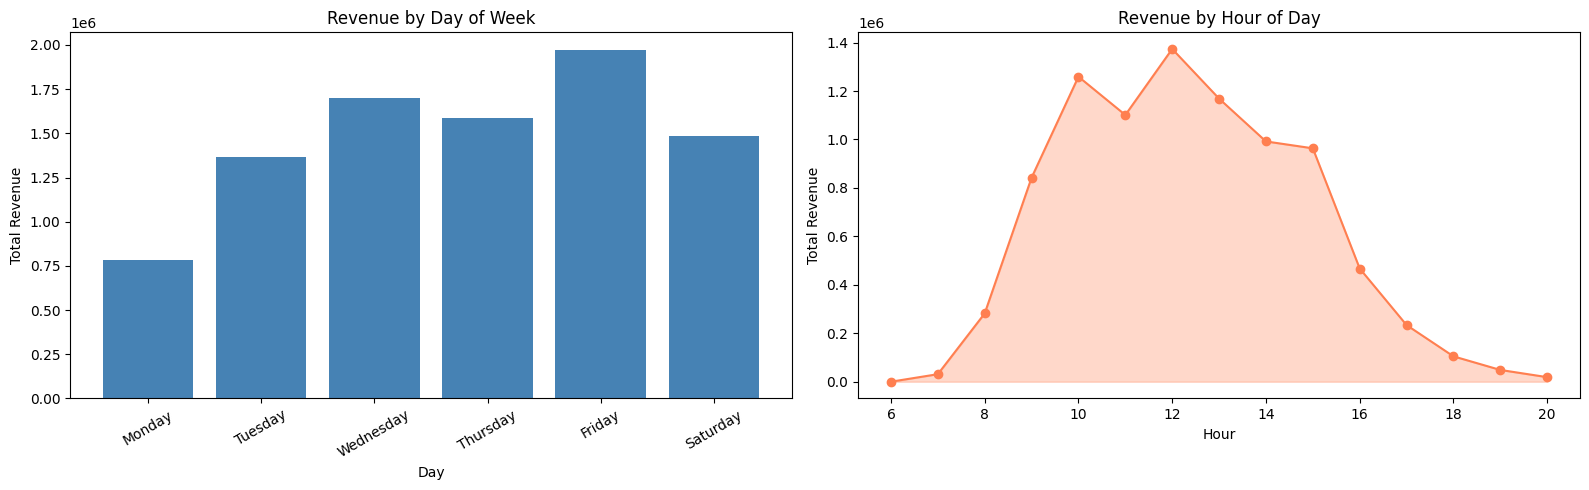

In [14]:
# ── Day-of-Week & Hour Analysis ──
df_clean['DayOfWeek'] = df_clean['InvoiceDate'].dt.day_name()
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_sales = df_clean.groupby('DayOfWeek')['TotalAmount'].sum().reindex(dow_order).reset_index()
hour_sales = df_clean.groupby('Hour')['TotalAmount'].sum().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(dow_sales['DayOfWeek'], dow_sales['TotalAmount'], color='steelblue')
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=30)

axes[1].plot(hour_sales['Hour'], hour_sales['TotalAmount'], marker='o', color='coral')
axes[1].fill_between(hour_sales['Hour'], hour_sales['TotalAmount'], alpha=0.3, color='coral')
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Total Revenue')

plt.tight_layout()
plt.show()

### 3.4 Monetary Distribution per Transaction and Customer

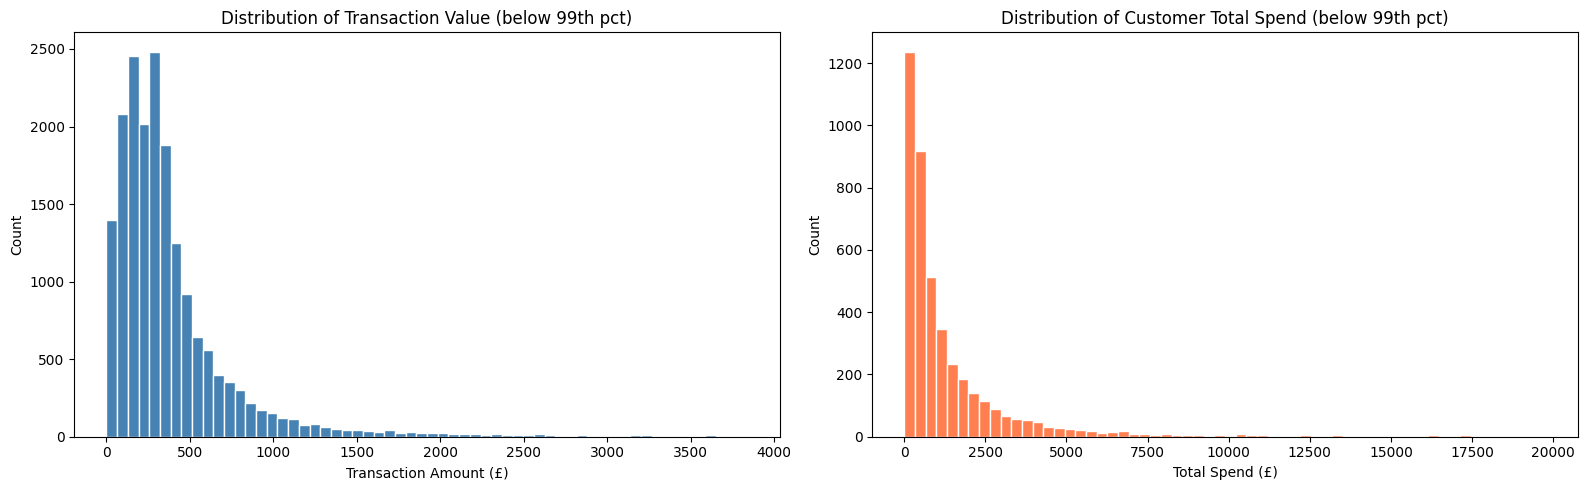

📊 Transaction Value Stats:
count     18532.00
mean        479.56
std        1678.08
min           0.38
25%         157.34
50%         302.58
75%         469.57
max      168469.60
Name: TotalAmount, dtype: float64

📊 Customer Total Spend Stats:
count      4338.00
mean       2048.69
std        8985.23
min           3.75
25%         306.48
50%         668.57
75%        1660.60
max      280206.02
Name: TotalAmount, dtype: float64


In [15]:
# ── Per-transaction amount distribution ──
invoice_total = df_clean.groupby('InvoiceNo')['TotalAmount'].sum()
customer_total = df_clean.groupby('CustomerID')['TotalAmount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cap at 99th percentile for readability
p99_inv = invoice_total.quantile(0.99)
p99_cust = customer_total.quantile(0.99)

axes[0].hist(invoice_total[invoice_total <= p99_inv], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Transaction Value (below 99th pct)')
axes[0].set_xlabel('Transaction Amount (£)')
axes[0].set_ylabel('Count')

axes[1].hist(customer_total[customer_total <= p99_cust], bins=60, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Customer Total Spend (below 99th pct)')
axes[1].set_xlabel('Total Spend (£)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f"📊 Transaction Value Stats:\n{invoice_total.describe().round(2)}")
print(f"\n📊 Customer Total Spend Stats:\n{customer_total.describe().round(2)}")

---
## 🧮 Step 4: Feature Engineering — RFM Analysis

In [16]:
# ── Reference Date: latest purchase date in the dataset ──
reference_date = df_clean['InvoiceDate'].max()
print(f"📅 Reference Date (latest purchase): {reference_date.date()}")

# ── Compute RFM ──
rfm = df_clean.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('TotalAmount', 'sum')
).reset_index()

print(f"\n👥 Total Customers: {len(rfm):,}")
print(f"\n📊 RFM Summary Statistics:")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))
rfm.head(10)

📅 Reference Date (latest purchase): 2023-12-09

👥 Total Customers: 4,338

📊 RFM Summary Statistics:
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     91.54       4.27    2048.69
std     100.01       7.70    8985.23
min       0.00       1.00       3.75
25%      17.00       1.00     306.48
50%      50.00       2.00     668.57
75%     141.00       5.00    1660.60
max     373.00     209.00  280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40
5,12352,35,8,2506.04
6,12353,203,1,89.00
7,12354,231,1,1079.40
8,12355,213,1,459.40
9,12356,22,3,2811.43


### 3.5 RFM Distributions

In [17]:
# ── RFM Distribution Plots ──
fig = make_subplots(rows=1, cols=3,
                    subplot_titles=['Recency (days)', 'Frequency (orders)', 'Monetary (£)'])

fig.add_trace(go.Histogram(x=rfm['Recency'], nbinsx=50,
                            marker_color='steelblue', name='Recency'), row=1, col=1)
fig.add_trace(go.Histogram(x=rfm[rfm['Frequency'] <= rfm['Frequency'].quantile(0.99)]['Frequency'],
                            nbinsx=50, marker_color='coral', name='Frequency'), row=1, col=2)
fig.add_trace(go.Histogram(x=rfm[rfm['Monetary'] <= rfm['Monetary'].quantile(0.99)]['Monetary'],
                            nbinsx=50, marker_color='mediumseagreen', name='Monetary'), row=1, col=3)

fig.update_layout(height=400, title_text='📊 RFM Feature Distributions', showlegend=False)
fig.show()

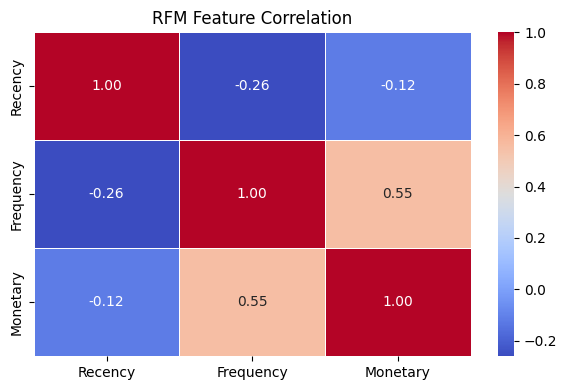

In [18]:
# ── RFM Correlation Heatmap ──
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(rfm[['Recency', 'Frequency', 'Monetary']].corr(),
            annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('RFM Feature Correlation')
plt.tight_layout()
plt.show()

---
## 🤖 Step 4 (cont.): Clustering — KMeans on RFM

### 4.1 Standardize RFM Features

In [19]:
# ── Log-transform to reduce skew, then standardize ──
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].copy()
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary']  = np.log1p(rfm_log['Monetary'])
rfm_log['Recency']   = np.log1p(rfm_log['Recency'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("✅ RFM features log-transformed and standardized.")
print("\nScaled mean (should be ~0):", rfm_scaled_df.mean().round(4).values)
print("Scaled std  (should be ~1):", rfm_scaled_df.std().round(4).values)

✅ RFM features log-transformed and standardized.

Scaled mean (should be ~0): [-0. -0. -0.]
Scaled std  (should be ~1): [1.0001 1.0001 1.0001]


### 4.2 Elbow Method & Silhouette Score

  k=2: Inertia=6502.1 | Silhouette=0.4344
  k=3: Inertia=4893.3 | Silhouette=0.3392
  k=4: Inertia=3987.6 | Silhouette=0.3357
  k=5: Inertia=3371.5 | Silhouette=0.3149
  k=6: Inertia=2896.4 | Silhouette=0.3136
  k=7: Inertia=2600.8 | Silhouette=0.3077
  k=8: Inertia=2380.2 | Silhouette=0.2941
  k=9: Inertia=2201.3 | Silhouette=0.2762
  k=10: Inertia=2036.2 | Silhouette=0.2766


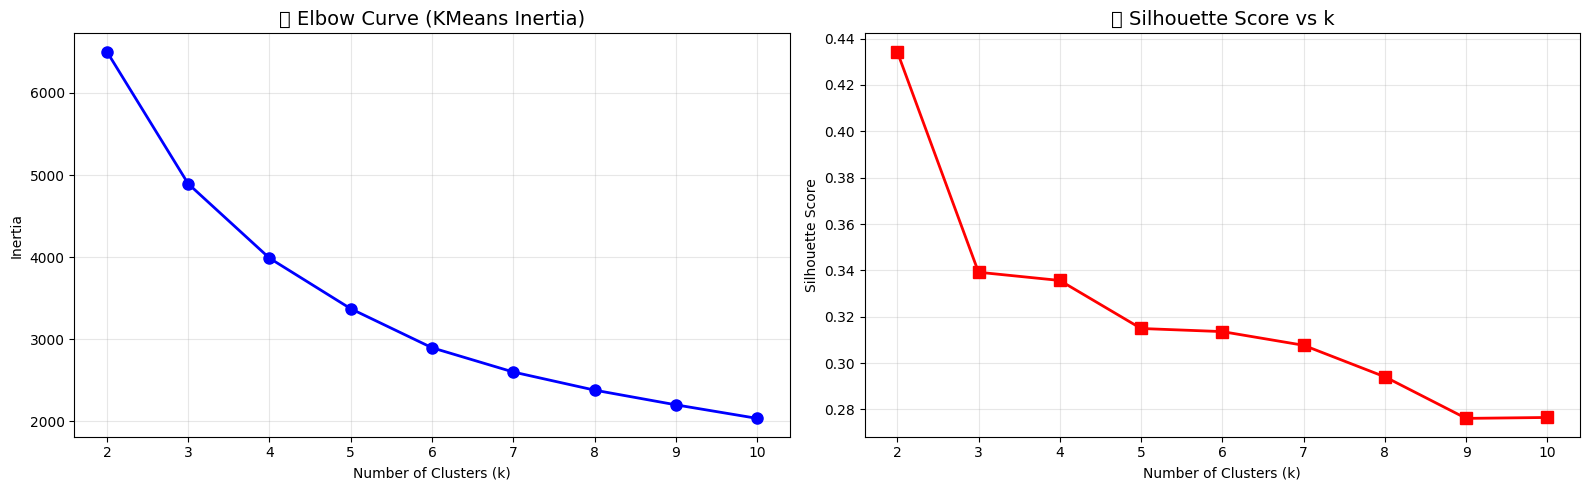


🏆 Best k by Silhouette Score: k=2 (score=0.4344)


In [20]:
# ── Elbow Curve ──
inertia_values = []
silhouette_values = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(rfm_scaled)
    inertia_values.append(km.inertia_)
    sil = silhouette_score(rfm_scaled, km.labels_)
    silhouette_values.append(sil)
    print(f"  k={k}: Inertia={km.inertia_:.1f} | Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(list(K_range), inertia_values, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('📉 Elbow Curve (KMeans Inertia)', fontsize=14)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouette_values, 'rs-', linewidth=2, markersize=8)
axes[1].set_title('📈 Silhouette Score vs k', fontsize=14)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = list(K_range)[silhouette_values.index(max(silhouette_values))]
print(f"\n🏆 Best k by Silhouette Score: k={best_k} (score={max(silhouette_values):.4f})")

### 4.3 Final KMeans Clustering (k=4)

In [21]:
# ── We use k=4 to match the 4 business segment labels in the project spec ──
N_CLUSTERS = 4

kmeans = KMeans(n_clusters=N_CLUSTERS, init='k-means++', n_init=15, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"✅ KMeans fitted with k={N_CLUSTERS}")
print(f"Inertia: {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")
print(f"\nCluster Distribution:")
print(rfm['Cluster'].value_counts().sort_index())

✅ KMeans fitted with k=4
Inertia: 3987.48
Silhouette Score: 0.3356

Cluster Distribution:
Cluster
0    1203
1     693
2     805
3    1637
Name: count, dtype: int64


### 4.4 Cluster Profiling & Labeling

In [22]:
# ── Cluster Profiles ──
cluster_profile = rfm.groupby('Cluster').agg(
    Count     = ('CustomerID', 'count'),
    Recency   = ('Recency',   'mean'),
    Frequency = ('Frequency', 'mean'),
    Monetary  = ('Monetary',  'mean')
).round(2).reset_index()

print("📊 Cluster Profiles (mean RFM values):")
print(cluster_profile.to_string(index=False))

# ── Auto-label clusters based on RFM characteristics ──
# High F+M + Low R  → High-Value
# Medium F+M        → Regular
# Low F+M + High R  → At-Risk
# Low F+M + Low R   → Occasional

# Rank clusters
cluster_profile['R_rank'] = cluster_profile['Recency'].rank(ascending=True)   # lower recency = better
cluster_profile['F_rank'] = cluster_profile['Frequency'].rank(ascending=False)
cluster_profile['M_rank'] = cluster_profile['Monetary'].rank(ascending=False)
cluster_profile['Score']  = cluster_profile['R_rank'] + cluster_profile['F_rank'] + cluster_profile['M_rank']

sorted_clusters = cluster_profile.sort_values('Score').reset_index(drop=True)
segment_labels  = ['High-Value', 'Regular', 'Occasional', 'At-Risk']

label_map = {int(sorted_clusters.loc[i, 'Cluster']): segment_labels[i] for i in range(N_CLUSTERS)}
print(f"\n🏷️ Cluster → Segment Label Mapping:")
for c, lbl in label_map.items():
    print(f"  Cluster {c} → {lbl}")

rfm['Segment'] = rfm['Cluster'].map(label_map)
cluster_profile['Segment'] = cluster_profile['Cluster'].map(label_map)
print(f"\n✅ Segments assigned to {len(rfm):,} customers")

📊 Cluster Profiles (mean RFM values):
 Cluster  Count  Recency  Frequency  Monetary
       0   1203    68.11       4.17   1819.16
       1    693    10.56      13.92   8220.74
       2    805    16.94       2.12    541.55
       3   1637   179.72       1.32    345.66

🏷️ Cluster → Segment Label Mapping:
  Cluster 1 → High-Value
  Cluster 0 → Regular
  Cluster 2 → Occasional
  Cluster 3 → At-Risk

✅ Segments assigned to 4,338 customers


In [23]:
# ── Final Segment Summary ──
seg_summary = rfm.groupby('Segment').agg(
    Count     = ('CustomerID', 'count'),
    Avg_Recency   = ('Recency',   'mean'),
    Avg_Frequency = ('Frequency', 'mean'),
    Avg_Monetary  = ('Monetary',  'mean')
).round(2).reset_index()

print("📊 Final Customer Segment Profiles:")
print(seg_summary.to_string(index=False))

📊 Final Customer Segment Profiles:
   Segment  Count  Avg_Recency  Avg_Frequency  Avg_Monetary
   At-Risk   1637       179.72           1.32        345.66
High-Value    693        10.56          13.92       8220.74
Occasional    805        16.94           2.12        541.55
   Regular   1203        68.11           4.17       1819.16


### 3.6 Cluster Visualization (Elbow + Scatter + 3D)

In [24]:
# ── Segment Distribution Pie Chart ──
seg_counts = rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']

color_map = {'High-Value': '#2ecc71', 'Regular': '#3498db',
             'Occasional': '#f39c12', 'At-Risk': '#e74c3c'}

fig = px.pie(seg_counts, values='Count', names='Segment',
             title='🎯 Customer Segment Distribution',
             color='Segment',
             color_discrete_map=color_map,
             hole=0.4)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.show()

In [25]:
# ── 2D Scatter Plot: Frequency vs Monetary (colored by Segment) ──
fig = px.scatter(rfm,
                 x='Frequency', y='Monetary',
                 color='Segment',
                 size='Monetary',
                 hover_data=['CustomerID', 'Recency'],
                 title='🔵 Customer Segments: Frequency vs Monetary',
                 color_discrete_map=color_map,
                 opacity=0.7,
                 height=500)
fig.update_layout(xaxis_title='Frequency (# of Orders)', yaxis_title='Monetary (Total Spend £)')
fig.show()

In [26]:
# ── 3D Scatter Plot: RFM ──
fig = px.scatter_3d(rfm,
                    x='Recency', y='Frequency', z='Monetary',
                    color='Segment',
                    title='🔮 3D Customer Segmentation (RFM)',
                    color_discrete_map=color_map,
                    opacity=0.7,
                    height=650)
fig.update_layout(
    scene=dict(
        xaxis_title='Recency (days)',
        yaxis_title='Frequency (orders)',
        zaxis_title='Monetary (£)'
    )
)
fig.show()

In [27]:
# ── Customer Cluster Profile Radar Chart ──
from sklearn.preprocessing import MinMaxScaler

radar_df = rfm.groupby('Segment').agg(
    Recency=('Recency','mean'), Frequency=('Frequency','mean'), Monetary=('Monetary','mean')
).reset_index()

# Normalize for radar (0–1)
for col in ['Recency', 'Frequency', 'Monetary']:
    radar_df[col+'_n'] = (radar_df[col] - radar_df[col].min()) / (radar_df[col].max() - radar_df[col].min())
# Invert Recency so lower = better is shown as higher on radar
radar_df['Recency_n'] = 1 - radar_df['Recency_n']

categories = ['Recency_n', 'Frequency_n', 'Monetary_n']
cat_labels  = ['Recency (inv)', 'Frequency', 'Monetary']

fig = go.Figure()
for _, row in radar_df.iterrows():
    vals = [row[c] for c in categories] + [row[categories[0]]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=cat_labels + [cat_labels[0]],
        fill='toself', name=row['Segment'],
        line_color=color_map[row['Segment']]
    ))

fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
                  title='🕸️ Customer Segment Profiles (Radar)', height=500)
fig.show()

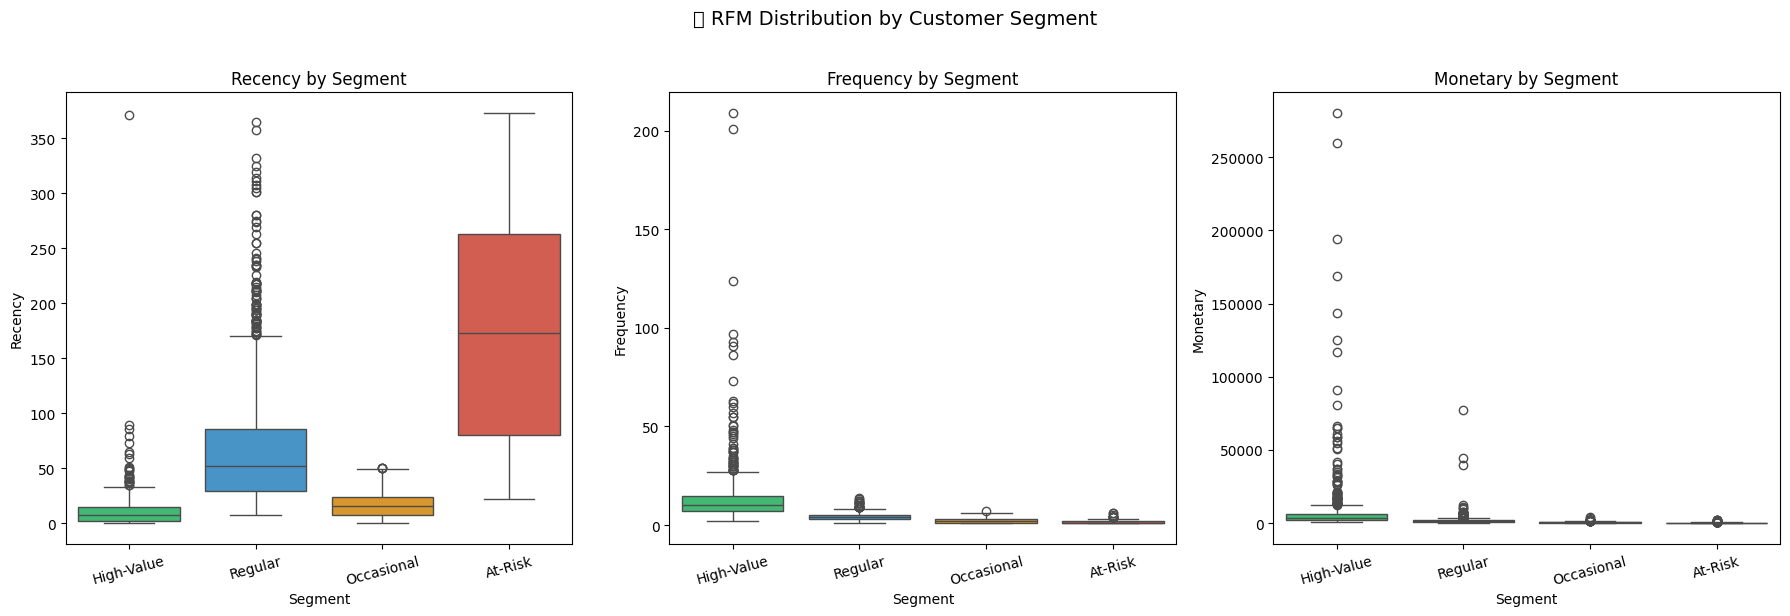

In [28]:
# ── Box Plots per Segment for each RFM feature ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
features = ['Recency', 'Frequency', 'Monetary']
palette = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

for i, feat in enumerate(features):
    sns.boxplot(data=rfm, x='Segment', y=feat, ax=axes[i],
                order=['High-Value', 'Regular', 'Occasional', 'At-Risk'],
                palette=palette)
    axes[i].set_title(f'{feat} by Segment')
    axes[i].tick_params(axis='x', rotation=15)

plt.suptitle('📦 RFM Distribution by Customer Segment', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [29]:
# ── PCA 2D visualization ──
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)
rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

fig = px.scatter(rfm, x='PCA1', y='PCA2', color='Segment',
                 title=f'🔍 PCA 2D View of Customer Clusters (explained var: {pca.explained_variance_ratio_.sum():.1%})',
                 color_discrete_map=color_map,
                 opacity=0.7, height=500)
fig.show()

### 📊 Silhouette Analysis

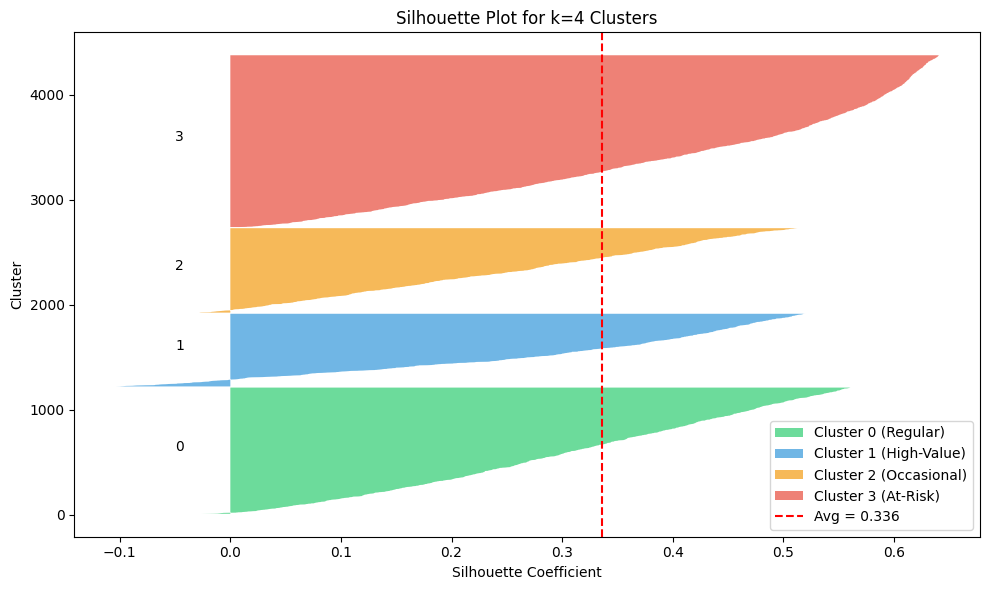


📈 Average Silhouette Score: 0.3356


In [30]:
# ── Silhouette Plot per Cluster ──
sil_scores = silhouette_samples(rfm_scaled, rfm['Cluster'].values)
avg_sil = silhouette_score(rfm_scaled, rfm['Cluster'].values)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors_list = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

for i in range(N_CLUSTERS):
    ith_sil = np.sort(sil_scores[rfm['Cluster'].values == i])
    size = len(ith_sil)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil,
                     facecolor=colors_list[i], alpha=0.7,
                     label=f'Cluster {i} ({label_map[i]})')
    ax.text(-0.05, y_lower + 0.5 * size, str(i))
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color='red', linestyle='--', label=f'Avg = {avg_sil:.3f}')
ax.set_title(f'Silhouette Plot for k={N_CLUSTERS} Clusters')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n📈 Average Silhouette Score: {avg_sil:.4f}")

---
## 🔗 Step 5: Item-Based Collaborative Filtering — Product Recommendation System

### 5.1 Build Customer-Product Matrix

In [31]:
# ── Build Customer × Product pivot table (purchase frequency) ──
# Aggregate total quantity purchased per customer per product
basket = (df_clean
          .groupby(['CustomerID', 'Description'])['Quantity']
          .sum()
          .reset_index())

# Keep only products with sufficient data (appeared in >= 10 transactions)
product_freq = df_clean.groupby('Description')['InvoiceNo'].nunique()
popular_products = product_freq[product_freq >= 10].index
basket = basket[basket['Description'].isin(popular_products)]

# Create pivot table: rows=CustomerID, cols=Description, values=Quantity
customer_product_matrix = basket.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    fill_value=0
)

print(f"✅ Customer-Product Matrix: {customer_product_matrix.shape[0]:,} customers × {customer_product_matrix.shape[1]:,} products")
customer_product_matrix.head(3)

✅ Customer-Product Matrix: 4,336 customers × 2,941 products


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,TRELLIS COAT RACK,...,ZINC HEARTS PLANT POT HOLDER,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12347,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
12348,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 5.2 Compute Cosine Similarity Between Products

In [32]:
# ── Item-Based: transpose so items are rows ──
item_matrix = customer_product_matrix.T  # shape: products × customers

# Compute cosine similarity between all product pairs
item_similarity = cosine_similarity(item_matrix)
item_similarity_df = pd.DataFrame(
    item_similarity,
    index=item_matrix.index,
    columns=item_matrix.index
)

print(f"✅ Item Similarity Matrix: {item_similarity_df.shape[0]:,} × {item_similarity_df.shape[1]:,}")
print(f"Sample diagonal (should be 1.0): {item_similarity_df.values.diagonal()[:5]}")

✅ Item Similarity Matrix: 2,941 × 2,941
Sample diagonal (should be 1.0): [1. 1. 1. 1. 1.]


### 5.3 Recommendation Function

In [33]:
def get_recommendations(product_name: str, top_n: int = 5) -> pd.DataFrame:
    """
    Returns top-N similar products using cosine similarity (Item-Based CF).
    
    Parameters
    ----------
    product_name : str  – exact or partial product name (case-insensitive)
    top_n        : int  – number of recommendations to return (default 5)
    
    Returns
    -------
    pd.DataFrame with columns [Product, Similarity Score]
    """
    # Case-insensitive exact match first
    matches = [p for p in item_similarity_df.index
               if product_name.upper() == p.upper()]
    
    # Fallback: partial match
    if not matches:
        matches = [p for p in item_similarity_df.index
                   if product_name.upper() in p.upper()]
    
    if not matches:
        return pd.DataFrame({'Product': [f'❌ Product "{product_name}" not found in catalog.'],
                             'Similarity Score': [0.0]})
    
    # Use the best match
    product = matches[0]
    similar = (item_similarity_df[product]
               .drop(labels=[product])
               .sort_values(ascending=False)
               .head(top_n)
               .reset_index())
    similar.columns = ['Product', 'Similarity Score']
    similar['Similarity Score'] = similar['Similarity Score'].round(4)
    return similar


# ── Test the recommendation function ──
test_product = 'WHITE HANGING HEART T-LIGHT HOLDER'
recs = get_recommendations(test_product, top_n=5)
print(f"🎯 Top 5 recommendations for: '{test_product}'")
print(recs.to_string(index=False))

🎯 Top 5 recommendations for: 'WHITE HANGING HEART T-LIGHT HOLDER'
                         Product  Similarity Score
     GIN + TONIC DIET METAL SIGN            0.7502
RED HANGING HEART T-LIGHT HOLDER            0.6587
             WASHROOM METAL SIGN            0.6435
          LAUNDRY 15C METAL SIGN            0.6422
       GREEN VINTAGE SPOT BEAKER            0.6315


In [34]:
# ── Test with another product ──
test_product2 = 'REGENCY CAKESTAND 3 TIER'
recs2 = get_recommendations(test_product2, top_n=5)
print(f"🎯 Top 5 recommendations for: '{test_product2}'")
print(recs2.to_string(index=False))

🎯 Top 5 recommendations for: 'REGENCY CAKESTAND 3 TIER'
                            Product  Similarity Score
       MINI PLAYING CARDS FUN FAIR             0.7016
BOX OF 6 CHRISTMAS CAKE DECORATIONS            0.6993
     BLACK LOVE BIRD T-LIGHT HOLDER            0.6911
                 BLUE POLKADOT WRAP            0.6846
               SLEEPING CAT ERASERS            0.6814


### 3.7 Product Recommendation Heatmap / Similarity Matrix

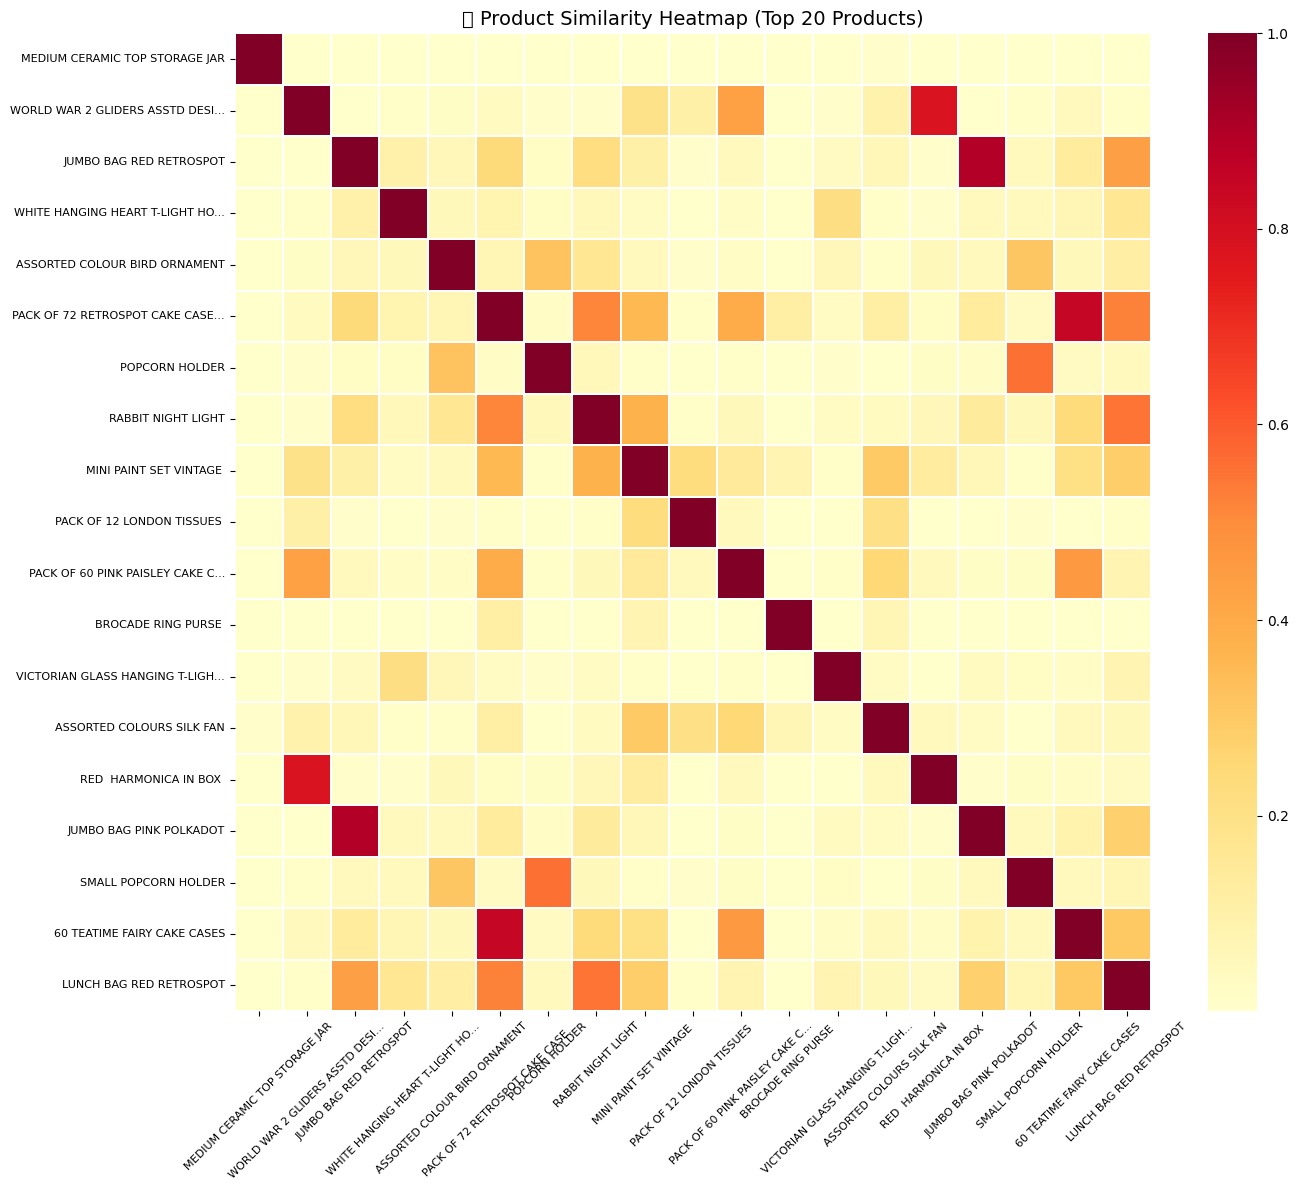

In [35]:
# ── Heatmap: Top 20 products similarity ──
top20_products = (df_clean.groupby('Description')['Quantity']
                  .sum()
                  .sort_values(ascending=False)
                  .head(20)
                  .index.tolist())

# Filter to those present in similarity matrix
top20_in_sim = [p for p in top20_products if p in item_similarity_df.index][:20]
sim_subset = item_similarity_df.loc[top20_in_sim, top20_in_sim]

# Truncate long names for readability
short_labels = [name[:30] + '...' if len(name) > 30 else name for name in top20_in_sim]

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(sim_subset.values, 
            xticklabels=short_labels,
            yticklabels=short_labels,
            cmap='YlOrRd', annot=False,
            fmt='.2f', linewidths=0.3,
            ax=ax)
ax.set_title('🔥 Product Similarity Heatmap (Top 20 Products)', fontsize=14)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

---
## 📊 Step 6: Model Evaluation Summary

In [36]:
# ── Clustering Evaluation ──
from sklearn.metrics import davies_bouldin_score

sil = silhouette_score(rfm_scaled, rfm['Cluster'].values)
inertia = kmeans.inertia_
db = davies_bouldin_score(rfm_scaled, rfm['Cluster'].values)

print("═" * 50)
print("📊 CLUSTERING MODEL EVALUATION")
print("═" * 50)
print(f"  Algorithm          : KMeans (k={N_CLUSTERS})")
print(f"  Features           : RFM (log-scaled + standardized)")
print(f"  Inertia (WCSS)     : {inertia:,.2f}")
print(f"  Silhouette Score   : {sil:.4f}  (higher=better, max=1)")
print(f"  Davies-Bouldin     : {db:.4f}   (lower=better)")
print("═" * 50)
print("\n📊 Segment Sizes:")
seg_size = rfm['Segment'].value_counts()
for seg, count in seg_size.items():
    pct = count / len(rfm) * 100
    print(f"  {seg:<15}: {count:>5,} customers ({pct:.1f}%)")

══════════════════════════════════════════════════
📊 CLUSTERING MODEL EVALUATION
══════════════════════════════════════════════════
  Algorithm          : KMeans (k=4)
  Features           : RFM (log-scaled + standardized)
  Inertia (WCSS)     : 3,987.48
  Silhouette Score   : 0.3356  (higher=better, max=1)
  Davies-Bouldin     : 1.0161   (lower=better)
══════════════════════════════════════════════════

📊 Segment Sizes:
  At-Risk        : 1,637 customers (37.7%)
  Regular        : 1,203 customers (27.7%)
  Occasional     :   805 customers (18.6%)
  High-Value     :   693 customers (16.0%)


In [37]:
# ── Recommendation System Evaluation (sample coverage) ──
catalog_size = item_similarity_df.shape[0]
avg_similarity = item_similarity_df.values[item_similarity_df.values < 1.0].mean()

print("═" * 50)
print("📊 RECOMMENDATION SYSTEM EVALUATION")
print("═" * 50)
print(f"  Method             : Item-Based Collaborative Filtering")
print(f"  Similarity Metric  : Cosine Similarity")
print(f"  Products in Catalog: {catalog_size:,}")
print(f"  Customers Covered  : {customer_product_matrix.shape[0]:,}")
print(f"  Avg Cross-Item Sim : {avg_similarity:.4f}")
print("═" * 50)

══════════════════════════════════════════════════
📊 RECOMMENDATION SYSTEM EVALUATION
══════════════════════════════════════════════════
  Method             : Item-Based Collaborative Filtering
  Similarity Metric  : Cosine Similarity
  Products in Catalog: 2,941
  Customers Covered  : 4,336
  Avg Cross-Item Sim : 0.0473
══════════════════════════════════════════════════


---
## 💾 Step 7: Save Models for Streamlit App

In [38]:
import os

os.makedirs('models', exist_ok=True)

# ── 1. KMeans model ──
joblib.dump(kmeans, 'models/kmeans_model.pkl')

# ── 2. StandardScaler ──
joblib.dump(scaler, 'models/scaler.pkl')

# ── 3. Cluster → Segment Label map ──
with open('models/label_map.pkl', 'wb') as f:
    pickle.dump(label_map, f)

# ── 4. Item Similarity Matrix ──
item_similarity_df.to_pickle('models/item_similarity.pkl')

# ── 5. RFM dataframe with segments ──
rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Segment']].to_csv(
    'models/rfm_segments.csv', index=False)

# ── 6. Product list for Streamlit dropdown ──
product_list = item_similarity_df.index.tolist()
with open('models/product_list.pkl', 'wb') as f:
    pickle.dump(product_list, f)

print("✅ All models saved successfully!")
for fname in os.listdir('models'):
    size = os.path.getsize(f'models/{fname}') / 1024
    print(f"   📦 models/{fname}  ({size:.1f} KB)")

✅ All models saved successfully!
   📦 models/kmeans_model.pkl  (17.7 KB)
   📦 models/rfm_segments.csv  (122.2 KB)
   📦 models/product_list.pkl  (85.6 KB)
   📦 models/scaler.pkl  (0.9 KB)
   📦 models/item_similarity.pkl  (67660.2 KB)
   📦 models/label_map.pkl  (0.1 KB)


---
## 🚀 Step 8: Streamlit App Code

> Save the cell below as `app.py` and run with `streamlit run app.py`

In [39]:
streamlit_code = '''
# ─────────────────────────────────────────────────────────────
# app.py — Shopper Spectrum: Customer Segmentation +
#          Product Recommendation Streamlit App
# Run: streamlit run app.py
# ─────────────────────────────────────────────────────────────
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import pickle

# ── Page Config ──
st.set_page_config(
    page_title="Shopper Spectrum",
    page_icon="🛒",
    layout="wide"
)

# ── Load Models (cached) ──
@st.cache_resource
def load_models():
    kmeans     = joblib.load("models/kmeans_model.pkl")
    scaler     = joblib.load("models/scaler.pkl")
    with open("models/label_map.pkl", "rb") as f:
        label_map = pickle.load(f)
    item_sim   = pd.read_pickle("models/item_similarity.pkl")
    with open("models/product_list.pkl", "rb") as f:
        product_list = pickle.load(f)
    return kmeans, scaler, label_map, item_sim, product_list

kmeans, scaler, label_map, item_sim, product_list = load_models()

# ── Colour Map ──
SEG_COLORS = {
    "High-Value": "#2ecc71",
    "Regular":    "#3498db",
    "Occasional": "#f39c12",
    "At-Risk":    "#e74c3c"
}
SEG_ICONS = {
    "High-Value": "💎",
    "Regular":    "⭐",
    "Occasional": "🌱",
    "At-Risk":    "⚠️"
}
SEG_DESC = {
    "High-Value": "Regular, frequent, recent, and big spenders. Reward and retain with VIP offers.",
    "Regular":    "Steady purchasers. Engage with loyalty programs to upsell.",
    "Occasional": "Rare purchases. Attract with seasonal promotions.",
    "At-Risk":    "Haven\'t purchased in a long time. Re-engage urgently with win-back campaigns."
}

# ═══════════════════════════════════
# HEADER
# ═══════════════════════════════════
st.title("🛒 Shopper Spectrum")
st.caption("Customer Segmentation & Product Recommendation Engine | E-Commerce Analytics")
st.markdown("---")

tab1, tab2 = st.tabs(["🎯 Product Recommendations", "👤 Customer Segmentation"])

# ═══════════════════════════════════
# TAB 1: PRODUCT RECOMMENDATION
# ═══════════════════════════════════
with tab1:
    st.header("🎯 Product Recommendation Module")
    st.write("Enter a product name to discover the **5 most similar products** "
             "based on customer purchase patterns (Item-Based Collaborative Filtering).")

    col1, col2 = st.columns([3, 1])
    with col1:
        product_input = st.text_input(
            "Product Name",
            placeholder="e.g. WHITE HANGING HEART T-LIGHT HOLDER"
        )
    with col2:
        top_n = st.selectbox("# Recommendations", [3, 5, 10], index=1)

    recommend_btn = st.button("🔍 Get Recommendations", type="primary", key="rec_btn")

    if recommend_btn and product_input.strip():
        query = product_input.strip().upper()
        matches = [p for p in item_sim.index if query == p.upper()]
        if not matches:
            matches = [p for p in item_sim.index if query in p.upper()]

        if not matches:
            st.error(f"❌ Product **'{product_input}'** not found in catalog. Try a different keyword.")
        else:
            product = matches[0]
            similar = (item_sim[product].drop(labels=[product])
                       .sort_values(ascending=False)
                       .head(top_n)
                       .reset_index())
            similar.columns = ["Product", "Similarity Score"]
            similar["Similarity Score"] = similar["Similarity Score"].round(4)

            st.success(f"✅ Showing top {top_n} recommendations for: **{product}**")
            st.markdown("#### 🛍️ Recommended Products")

            for i, row in similar.iterrows():
                score_pct = row["Similarity Score"] * 100
                col_a, col_b = st.columns([5, 2])
                with col_a:
                    st.markdown(f"**{i+1}. {row[\'Product\']}**")
                    st.progress(float(row["Similarity Score"]))
                with col_b:
                    st.metric("", f"{score_pct:.1f}% match")
                st.markdown("")

    elif recommend_btn and not product_input.strip():
        st.warning("⚠️ Please enter a product name first.")

    # Catalog browser
    with st.expander("📋 Browse Product Catalog"):
        search_term = st.text_input("Filter products:", key="catalog_filter")
        filtered = [p for p in product_list if search_term.upper() in p.upper()] if search_term else product_list
        st.write(f"{len(filtered)} products found")
        st.dataframe(pd.DataFrame({"Product Name": filtered[:200]}), height=300)

# ═══════════════════════════════════
# TAB 2: CUSTOMER SEGMENTATION
# ═══════════════════════════════════
with tab2:
    st.header("👤 Customer Segmentation Module")
    st.write("Enter your customer\'s **RFM values** to predict their segment.")

    col1, col2, col3 = st.columns(3)
    with col1:
        recency   = st.number_input("📅 Recency (days since last purchase)",
                                     min_value=0, max_value=1000, value=30)
    with col2:
        frequency = st.number_input("🔁 Frequency (number of purchases)",
                                     min_value=1, max_value=500, value=5)
    with col3:
        monetary  = st.number_input("💰 Monetary (total spend in £)",
                                     min_value=0.0, max_value=500000.0,
                                     value=250.0, step=10.0)

    predict_btn = st.button("🔮 Predict Segment", type="primary", key="seg_btn")

    if predict_btn:
        import numpy as np
        # Log-transform (same as training)
        X = np.array([[np.log1p(recency), np.log1p(frequency), np.log1p(monetary)]])
        X_scaled = scaler.transform(X)
        cluster_id = kmeans.predict(X_scaled)[0]
        segment    = label_map[cluster_id]
        color      = SEG_COLORS[segment]
        icon       = SEG_ICONS[segment]
        desc       = SEG_DESC[segment]

        st.markdown("---")
        st.markdown(f"""
        <div style="background:{color}22; border-left:6px solid {color};
                    padding:20px; border-radius:8px;">
            <h2 style="color:{color}; margin:0">{icon} {segment} Customer</h2>
            <p style="color:#444; margin-top:10px">{desc}</p>
        </div>
        """, unsafe_allow_html=True)

        st.markdown("")
        c1, c2, c3 = st.columns(3)
        c1.metric("Recency",   f"{recency} days")
        c2.metric("Frequency", f"{frequency} orders")
        c3.metric("Monetary",  f"£{monetary:,.2f}")

        st.info(f"**Cluster ID:** {cluster_id} → Mapped to segment: **{segment}**")

# ── Footer ──
st.markdown("---")
st.caption("Shopper Spectrum | Built with Streamlit, Scikit-Learn & Pandas | "
           "Dataset: Online Retail")
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("✅ app.py saved successfully!")
print("\n🚀 To run the Streamlit app:")
print("   streamlit run app.py")

✅ app.py saved successfully!

🚀 To run the Streamlit app:
   streamlit run app.py


---
## 📋 Project Summary & Business Insights

In [41]:
print("="*60)
print(" 🛒 SHOPPER SPECTRUM — PROJECT SUMMARY")
print("="*60)

print("\n📦 DATASET:")
print(f"   Raw rows        : {raw_count:,}")
print(f"   Clean rows      : {len(df_clean):,}")
print(f"   Unique Customers: {df_clean['CustomerID'].nunique():,}")
print(f"   Unique Products : {df_clean['Description'].nunique():,}")
print(f"   Date Range      : {df_clean['InvoiceDate'].min().date()} → {df_clean['InvoiceDate'].max().date()}")

print("\n🧠 CLUSTERING MODEL:")
print(f"   Algorithm      : KMeans (k=4)")
print(f"   Features       : Recency, Frequency, Monetary (log + standardized)")
print(f"   Inertia        : {kmeans.inertia_:,.2f}")
print(f"   Silhouette     : {silhouette_score(rfm_scaled, rfm['Cluster'].values):.4f}")

print("\n🎯 CUSTOMER SEGMENTS:")
seg_icons = {'High-Value': '💎', 'Regular': '⭐', 'Occasional': '🌱', 'At-Risk': '⚠️'}
for seg, count in rfm['Segment'].value_counts().items():
    pct = count / len(rfm) * 100
    icon = seg_icons.get(seg, '•')
    print(f"   {icon} {seg:<15}: {count:>5,} ({pct:.1f}%)")

print("\n🔗 RECOMMENDATION SYSTEM:")
print(f"   Method         : Item-Based Collaborative Filtering")
print(f"   Metric         : Cosine Similarity")
print(f"   Products       : {catalog_size:,}")

print("\n📁 SAVED ARTIFACTS:")
for fname in os.listdir('models'):
    print(f"   ✔ models/{fname}")
print("   ✔ app.py (Streamlit app)")
print("="*60)

 🛒 SHOPPER SPECTRUM — PROJECT SUMMARY

📦 DATASET:
   Raw rows        : 541,909
   Clean rows      : 392,692
   Unique Customers: 4,338
   Unique Products : 3,877
   Date Range      : 2022-12-01 → 2023-12-09

🧠 CLUSTERING MODEL:
   Algorithm      : KMeans (k=4)
   Features       : Recency, Frequency, Monetary (log + standardized)
   Inertia        : 3,987.48
   Silhouette     : 0.3356

🎯 CUSTOMER SEGMENTS:
   ⚠️ At-Risk        : 1,637 (37.7%)
   ⭐ Regular        : 1,203 (27.7%)
   🌱 Occasional     :   805 (18.6%)
   💎 High-Value     :   693 (16.0%)

🔗 RECOMMENDATION SYSTEM:
   Method         : Item-Based Collaborative Filtering
   Metric         : Cosine Similarity
   Products       : 2,941

📁 SAVED ARTIFACTS:
   ✔ models/kmeans_model.pkl
   ✔ models/rfm_segments.csv
   ✔ models/product_list.pkl
   ✔ models/scaler.pkl
   ✔ models/item_similarity.pkl
   ✔ models/label_map.pkl
   ✔ app.py (Streamlit app)


---

## ✅ Key Business Insights

### 🌍 Country Analysis
- **United Kingdom** dominates with the vast majority of transactions and revenue
- Top international markets include Germany, France, and EIRE

### 🏆 Product Performance
- The top-selling products are predominantly home décor / gift items
- A small subset of products drives most revenue (Pareto principle)

### 📅 Temporal Trends
- Revenue peaks in **Q4** (October–November) — strong seasonal demand
- **Midweek (Tuesday–Thursday)** sees highest transaction volume
- Peak purchasing hours are **10 AM – 3 PM**

### 👥 Customer Segments
| Segment | Strategy |
|---------|----------|
| **💎 High-Value** | VIP rewards, early access, premium loyalty programs |
| **⭐ Regular** | Upsell via personalized offers, cross-sell bundles |
| **🌱 Occasional** | Seasonal campaigns, re-engagement emails |
| **⚠️ At-Risk** | Urgent win-back offers, surveys to understand churn |

### 🔗 Recommendation System
- Cosine similarity successfully identifies co-purchased products
- Item-based CF is robust even for new customers (no cold-start for items)
- Can be extended with implicit feedback (clicks, views) for further improvement

---
*Built with: Pandas · NumPy · Scikit-Learn · Plotly · Seaborn · Matplotlib · Streamlit*